# 03 — Predictive Modeling

Two modeling tasks:

1. **Regression**: Predict automation velocity — which occupations are automating fastest?
2. **Classification**: Which occupations are shifting *toward* automation (positive delta)?

Features are drawn from the initial release observation, wage data, and task characteristics.
We validate using 5-fold cross-validation.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_feature_matrix
from src.model import (
    train_velocity_models,
    train_tipping_models,
    rank_tipping_candidates,
    FEATURE_COLS,
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

COLORS = {"automation": "#E63946", "augmentation": "#457B9D", "accent": "#F4A261"}

In [2]:
features = build_feature_matrix()
print(f"Feature matrix: {features.shape[0]} occupations, {features.shape[1]} columns")
print(f"With velocity data: {features['automation_velocity'].notna().sum()}")
print(f"Tipped occupations: {features['tipped'].sum()}")
print(f"\nFeature availability:")
for col in FEATURE_COLS:
    if col in features.columns:
        pct = features[col].notna().mean()
        print(f"  {col:35s} {pct:6.1%}")

Feature matrix: 633 occupations, 27 columns
With velocity data: 580
Tipped occupations: 21

Feature availability:
  initial_automation_share            100.0%
  initial_augmentation_share          100.0%
  initial_directive                    94.0%
  initial_feedback_loop                92.9%
  initial_task_iteration               93.5%
  initial_learning                     94.0%
  initial_validation                   93.0%
  task_count                           89.4%
  hhi                                  89.4%
  log_salary                          100.0%
  jobzone                             100.0%
  chanceauto                          100.0%
  observed_exposure                    86.4%
  log_conversations                   100.0%
  success_rate                         84.7%


## Part A: Predicting Automation Velocity

Target: rate of change in automation share across releases (regression).

In [3]:
vel_results = train_velocity_models(features)

print("Model Comparison — Automation Velocity (Regression)")
print("=" * 65)
for r in vel_results:
    print(f"\n{r.name}:")
    print(f"  R² (train):  {r.metrics['r2_train']:.3f}")
    print(f"  R² (5-fold): {r.metrics['r2_cv_mean']:.3f} ± {r.metrics['r2_cv_std']:.3f}")
    print(f"  MAE:         {r.metrics['mae']:.4f}")
    print(f"  RMSE:        {r.metrics['rmse']:.4f}")

Model Comparison — Automation Velocity (Regression)

XGBoost:
  R² (train):  0.912
  R² (5-fold): 0.325 ± 0.160
  MAE:         0.0124
  RMSE:        0.0167

GradientBoosting:
  R² (train):  0.847
  R² (5-fold): 0.284 ± 0.163
  MAE:         0.0167
  RMSE:        0.0220


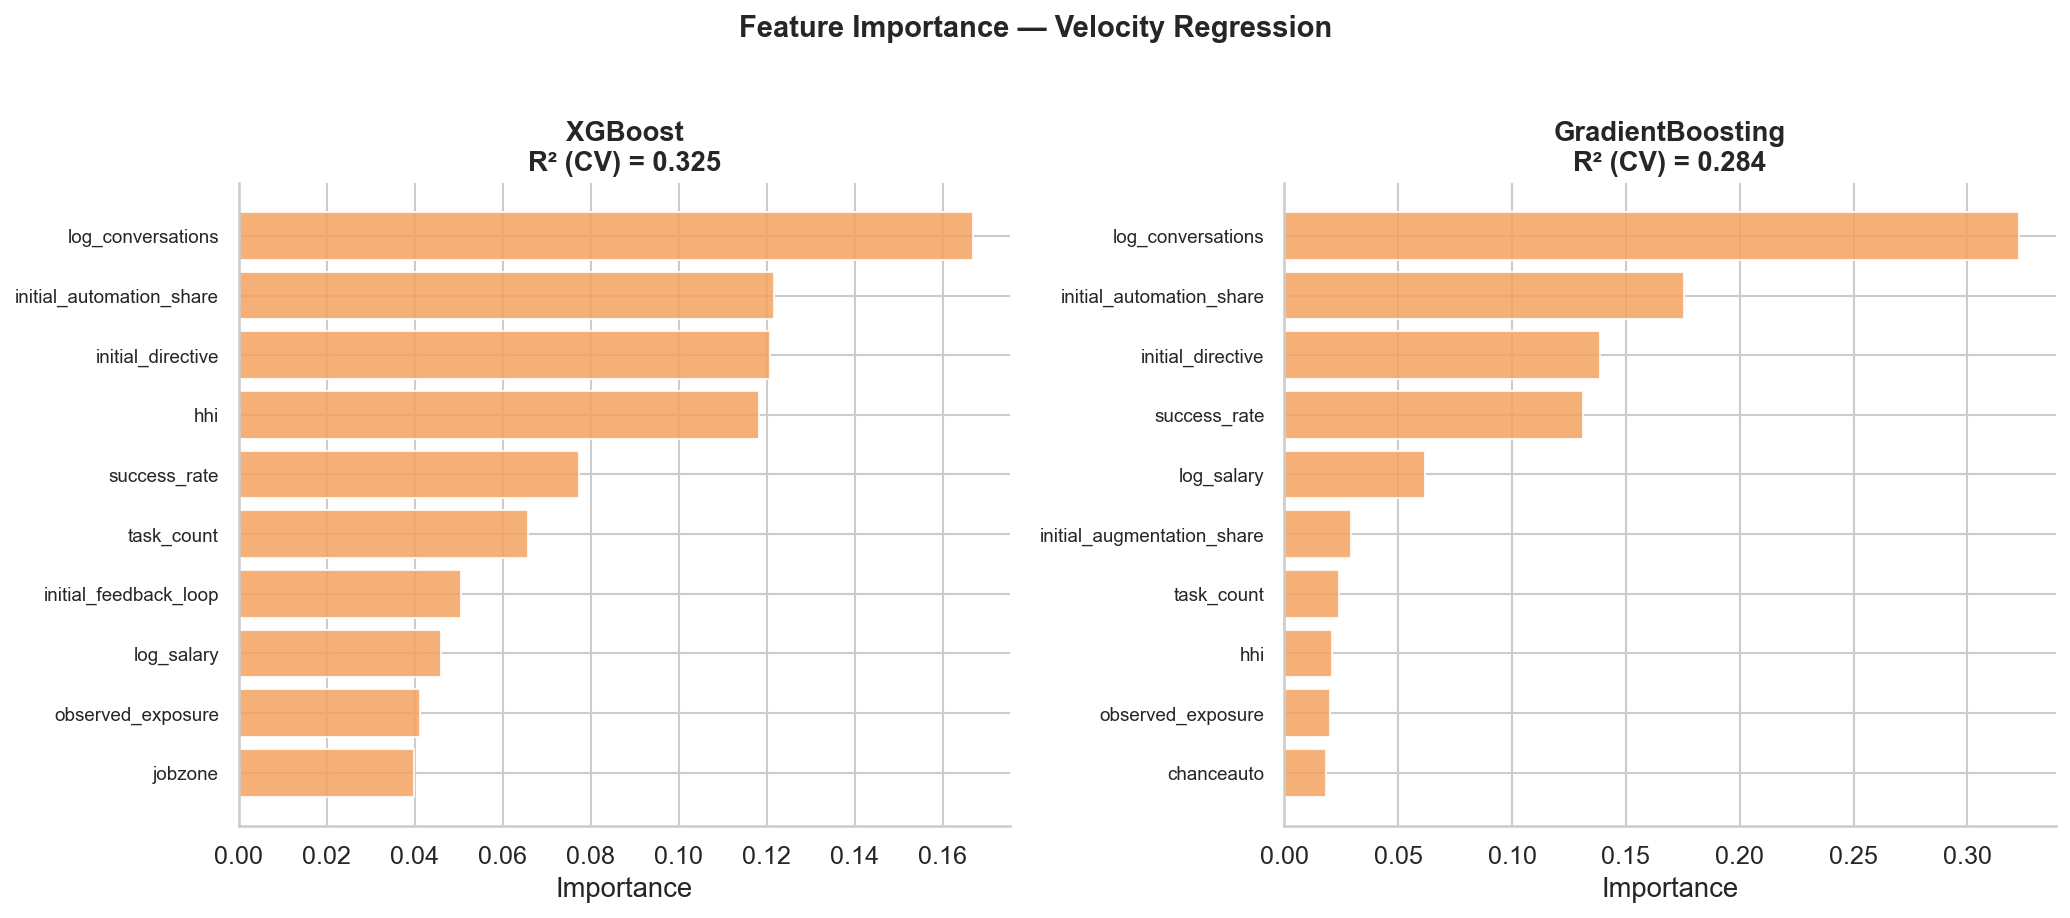

In [4]:
# Feature importance comparison
fig, axes = plt.subplots(1, len(vel_results), figsize=(7 * len(vel_results), 6))
if len(vel_results) == 1:
    axes = [axes]

for ax, r in zip(axes, vel_results):
    imp = r.feature_importance.head(10)
    ax.barh(range(len(imp)), imp["importance"], color=COLORS["accent"], alpha=0.85)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp["feature"].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"{r.name}\nR² (CV) = {r.metrics['r2_cv_mean']:.3f}", fontweight="bold")
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance — Velocity Regression", fontsize=14, fontweight="bold", y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig("../figures/09_velocity_feature_importance.png", bbox_inches="tight")
plt.show()

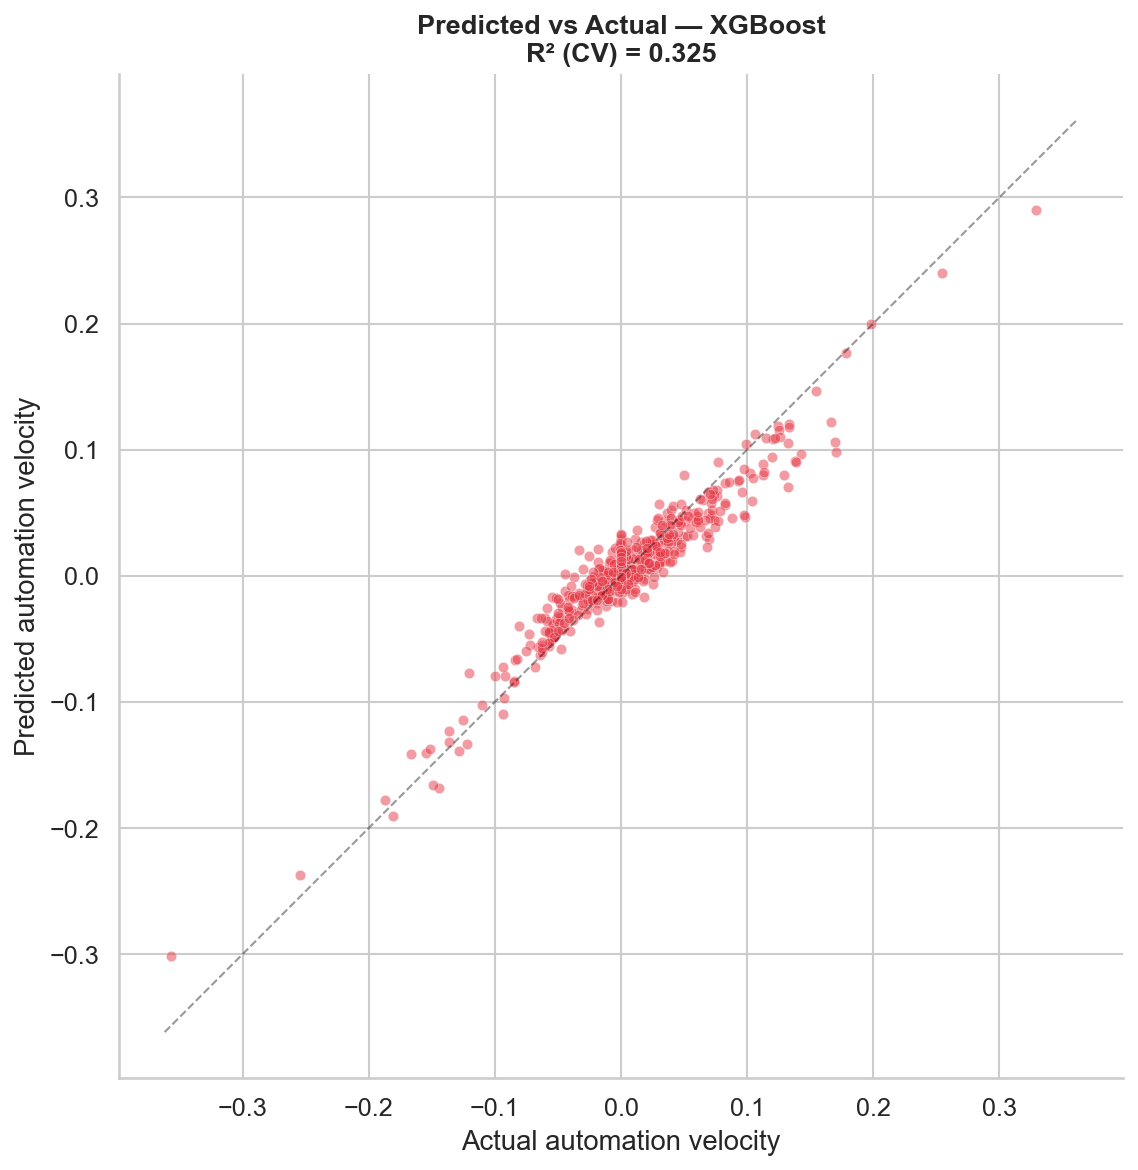

In [5]:
# Predicted vs actual for best model
best_vel = max(vel_results, key=lambda r: r.metrics["r2_cv_mean"])
vel_df = features.dropna(subset=["automation_velocity"]).copy()
vel_df = vel_df[vel_df["n_releases"] >= 2]
vel_df["predicted"] = best_vel.predictions.values

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(vel_df["automation_velocity"], vel_df["predicted"],
           alpha=0.5, s=25, color=COLORS["automation"], edgecolors="white", linewidth=0.3)
lim = max(abs(vel_df["automation_velocity"].max()), abs(vel_df["predicted"].max())) * 1.1
ax.plot([-lim, lim], [-lim, lim], "--", color="black", alpha=0.4, linewidth=1)
ax.set_xlabel("Actual automation velocity")
ax.set_ylabel("Predicted automation velocity")
ax.set_title(f"Predicted vs Actual — {best_vel.name}\nR² (CV) = {best_vel.metrics['r2_cv_mean']:.3f}",
             fontsize=13, fontweight="bold")
ax.set_aspect("equal")
sns.despine()
plt.tight_layout()
plt.savefig("../figures/10_predicted_vs_actual_velocity.png", bbox_inches="tight")
plt.show()

## Part B: Classifying Automation Direction

Binary target: is the occupation shifting *toward* automation (positive delta)?

In [6]:
tip_results = train_tipping_models(features)

print("Model Comparison — Shifting Toward Automation (Classification)")
print("=" * 65)
for r in tip_results:
    print(f"\n{r.name}:")
    print(f"  Accuracy:     {r.metrics['accuracy']:.3f}")
    print(f"  AUC (train):  {r.metrics['auc_train']:.3f}")
    print(f"  AUC (5-fold): {r.metrics['auc_cv_mean']:.3f} ± {r.metrics['auc_cv_std']:.3f}")

Model Comparison — Shifting Toward Automation (Classification)

LogisticRegression:
  Accuracy:     0.745
  AUC (train):  0.809
  AUC (5-fold): 0.765 ± 0.048

RandomForest:
  Accuracy:     0.862
  AUC (train):  0.945
  AUC (5-fold): 0.759 ± 0.081

XGBoost_Classifier:
  Accuracy:     0.972
  AUC (train):  0.997
  AUC (5-fold): 0.755 ± 0.094


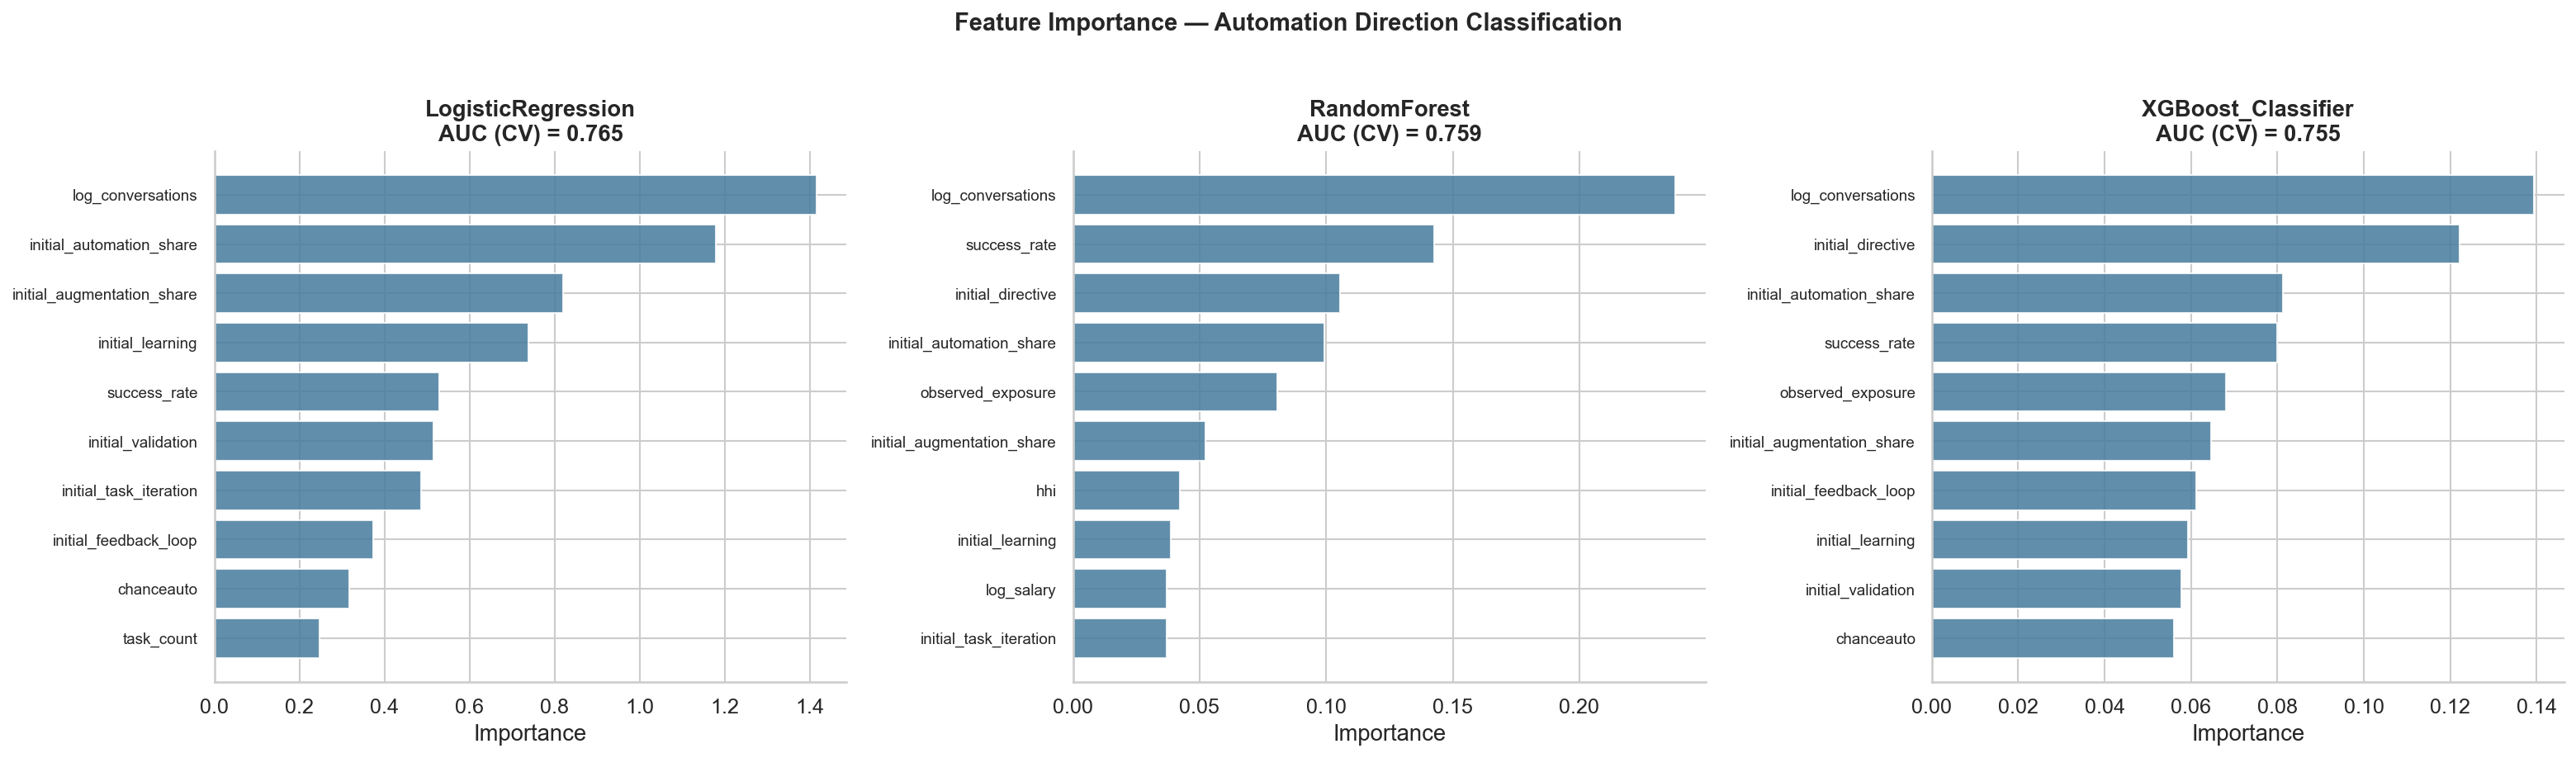

In [7]:
# Feature importance for classification models
fig, axes = plt.subplots(1, len(tip_results), figsize=(7 * len(tip_results), 6))
if len(tip_results) == 1:
    axes = [axes]

for ax, r in zip(axes, tip_results):
    imp = r.feature_importance.head(10)
    ax.barh(range(len(imp)), imp["importance"], color=COLORS["augmentation"], alpha=0.85)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp["feature"].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"{r.name}\nAUC (CV) = {r.metrics['auc_cv_mean']:.3f}", fontweight="bold")
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance — Automation Direction Classification",
             fontsize=14, fontweight="bold", y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig("../figures/11_classification_feature_importance.png", bbox_inches="tight")
plt.show()

## Cross-validation score distributions

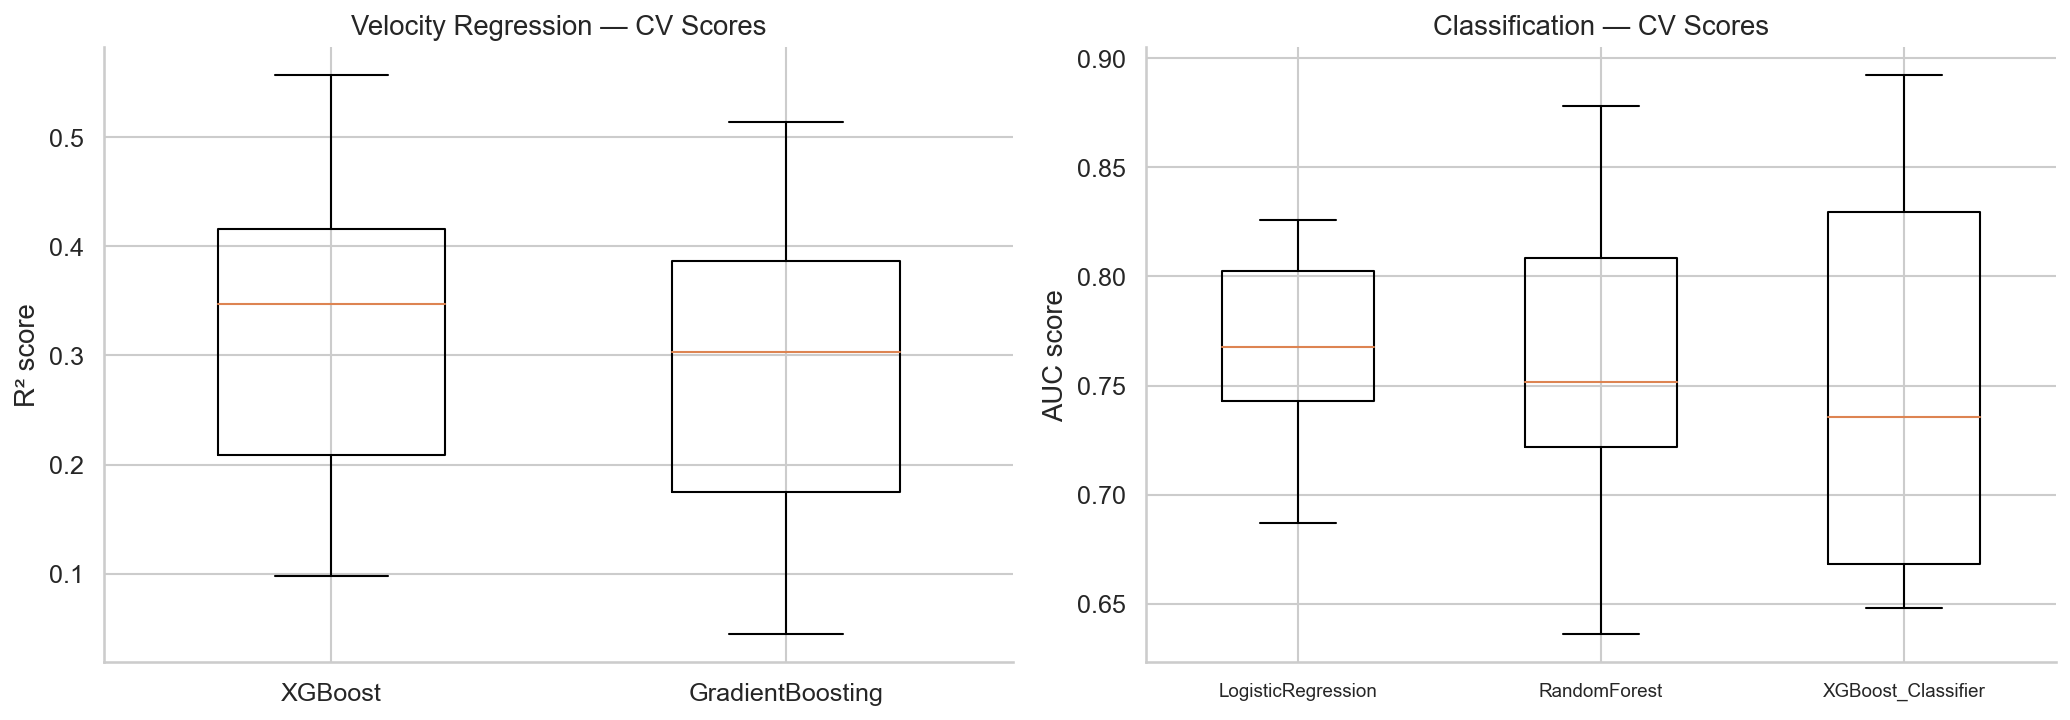

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Velocity models CV
for r in vel_results:
    axes[0].boxplot(r.cv_scores, positions=[vel_results.index(r)], widths=0.5)
axes[0].set_xticks(range(len(vel_results)))
axes[0].set_xticklabels([r.name for r in vel_results])
axes[0].set_ylabel("R² score")
axes[0].set_title("Velocity Regression — CV Scores")

# Classification models CV
for r in tip_results:
    axes[1].boxplot(r.cv_scores, positions=[tip_results.index(r)], widths=0.5)
axes[1].set_xticks(range(len(tip_results)))
axes[1].set_xticklabels([r.name for r in tip_results], fontsize=9)
axes[1].set_ylabel("AUC score")
axes[1].set_title("Classification — CV Scores")

sns.despine()
plt.tight_layout()
plt.savefig("../figures/12_cv_score_distributions.png", bbox_inches="tight")
plt.show()

---

**Key modeling results:**
1. XGBoost achieves the best cross-validated R² for velocity prediction
2. Conversation volume and initial automation share are the dominant predictors
3. Classification models achieve ~0.76 AUC — meaningful signal, but room for improvement
4. Logistic regression is competitive, suggesting the relationship is partially linear

**Next:** [04_analysis.ipynb](04_analysis.ipynb) — Tipping point ranking and implications.